# Phase 06 — Evaluation & Results

> *AUC-ROC, F1, precision-recall curve, confusion matrix, ablation studies, baseline comparison (MLP vs GNN), t-SNE embedding visualization.*

This notebook provides a comprehensive evaluation of the trained Relational Fraud GNN from Phase 05.
It loads the best saved checkpoint, runs inference on the test set, and produces all key evaluation artifacts.

## 6.1 — Imports & Setup

In [1]:
import math, os, time, warnings, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.manifold import TSNE
from torch_geometric.loader import NeighborLoader

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

DATA_DIR = Path('/content/sample_data')
if not DATA_DIR.exists():
    DATA_DIR = Path('content/sample_data')

print(f'Data   : {DATA_DIR}')

Device : cpu
Data   : content\sample_data


## 6.2 — Load Graph, Model & Checkpoint

In [2]:
# Run Phase 04 to get model class definitions
%run Phase04_GNN_Model.ipynb


Loaded graph from: content\sample_data\hetero_data.pt
HeteroData(
  graph_info={
    entity_cols={
      ProductCD='product',
      card1='card1',
      card2='card2',
      card3='card3',
      card4='card4',
      card5='card5',
      card6='card6',
      addr1='addr1',
      addr2='addr2',
      P_emaildomain='email_p',
      R_emaildomain='email_r',
      DeviceType='device_type',
      DeviceInfo='device_info',
    },
    transaction_feature_cols=[45],
    min_count_threshold=5,
    random_state=42,
    split={
      train=0.7,
      val=0.15,
      test=0.15,
    },
    entity_feature_cols=[2],
  },
  entity_mappings={
    ProductCD={
      4=0,
      0=1,
      2=2,
      1=3,
      3=4,
      __rare__=5,
    },
    card1={
      7919=0,
      9500=1,
      15885=2,
      17188=3,
      15066=4,
      12695=5,
      12544=6,
      6019=7,
      2803=8,
      7585=9,
      10616=10,
      12839=11,
      3154=12,
      2616=13,
      18132=14,
      9633=15,
      15497=16,
     

In [3]:
# Load graph
graph_path = DATA_DIR / 'hetero_data.pt'
data = torch.load(graph_path, map_location='cpu', weights_only=False)
print(f'Graph loaded: {data["transaction"].num_nodes:,} transactions')

# Load best checkpoint
BEST_CKPT = DATA_DIR / 'best_fraud_gnn.pt'
best_ckpt = torch.load(BEST_CKPT, map_location='cpu', weights_only=False)
model_config = best_ckpt['model_config']
input_dims = best_ckpt['input_dims']
metadata = best_ckpt['metadata']

model = RelationalFraudGNN(
    metadata=metadata,
    input_dims=input_dims,
    hidden_dim=model_config['hidden_dim'],
    num_heads=model_config['num_heads'],
    num_layers=model_config['num_layers'],
    dropout=model_config['dropout'],
    num_classes=model_config['num_classes'],
).to(DEVICE)

model.load_state_dict(best_ckpt['model_state_dict'])
print(f'Loaded best checkpoint from epoch {best_ckpt["epoch"]}')
print(f'  Val ROC-AUC : {best_ckpt["val_roc_auc"]:.4f}')
print(f'  Val PR-AUC  : {best_ckpt["val_pr_auc"]:.4f}')
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Parameters  : {n_params:,}')

Graph loaded: 590,540 transactions
Loaded best checkpoint from epoch 17
  Val ROC-AUC : 0.8302
  Val PR-AUC  : 0.4103
  Parameters  : 1,334,914


## 6.3 — Prepare Test DataLoader

In [4]:
BATCH_SIZE = 2048
NUM_NEIGHBORS = [15, 10, 5]

test_loader = NeighborLoader(
    data,
    input_nodes=('transaction', data['transaction'].test_mask),
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE,
    num_workers=0,
    shuffle=False,
)
print(f'Test batches: {len(test_loader)}')

Test batches: 44


## 6.4 — Run Test-Set Inference

In [5]:
@torch.no_grad()
def evaluate_with_embeddings(loader):
    """Run inference and collect predictions + last-layer embeddings."""
    model.eval()
    all_probs, all_labels, all_embeds = [], [], []
    total_loss = 0.0

    # Focal loss for consistency with training
    train_y = data['transaction'].y[data['transaction'].train_mask]
    num_fraud = train_y.sum().item()
    num_legit = (train_y == 0).sum().item()
    fraud_wt = num_legit / (num_fraud + 1e-8)
    class_weights = torch.tensor([1.0, fraud_wt], dtype=torch.float).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    for batch in loader:
        batch = batch.to(DEVICE)
        batch_size = batch['transaction'].batch_size
        result = model(batch)

        # model returns (logits, embeddings_dict_or_tensor)
        if isinstance(result, tuple):
            logits = result[0]
            raw_embeds = result[1] if len(result) > 1 else None
        else:
            logits = result
            raw_embeds = None

        loss = criterion(logits[:batch_size], batch['transaction'].y[:batch_size])
        total_loss += loss.item()

        probs = torch.softmax(logits[:batch_size], dim=-1)[:, 1]
        all_probs.append(probs.cpu().numpy())
        all_labels.append(batch['transaction'].y[:batch_size].cpu().numpy())

        # Handle embeddings — could be dict, tensor, or None
        if raw_embeds is not None:
            if isinstance(raw_embeds, dict):
                emb = raw_embeds.get('transaction', None)
                if emb is not None:
                    all_embeds.append(emb[:batch_size].detach().cpu().numpy())
            elif isinstance(raw_embeds, torch.Tensor):
                all_embeds.append(raw_embeds[:batch_size].detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    all_embeds = np.concatenate(all_embeds) if all_embeds else None
    roc_auc = roc_auc_score(all_labels, all_probs)
    pr_auc = average_precision_score(all_labels, all_probs)

    return total_loss / len(loader), roc_auc, pr_auc, all_probs, all_labels, all_embeds

test_loss, test_roc, test_pr, test_probs, test_labels, test_embeds = evaluate_with_embeddings(test_loader)

print(f'TEST ROC-AUC  : {test_roc:.4f}')
print(f'TEST PR-AUC   : {test_pr:.4f}')
print(f'TEST Loss     : {test_loss:.4f}')
if test_embeds is not None:
    print(f'Embeddings    : {test_embeds.shape}')
else:
    print('Embeddings    : not available (model does not return transaction embeddings)')

TEST ROC-AUC  : 0.8316
TEST PR-AUC   : 0.4130
TEST Loss     : 0.5615
Embeddings    : (88581, 64)


## 6.5 — AUC-ROC & Precision-Recall Curves

These are the two primary ranking metrics for fraud detection:
- **ROC-AUC** measures overall discrimination ability.
- **PR-AUC** (Average Precision) is more informative under class imbalance.

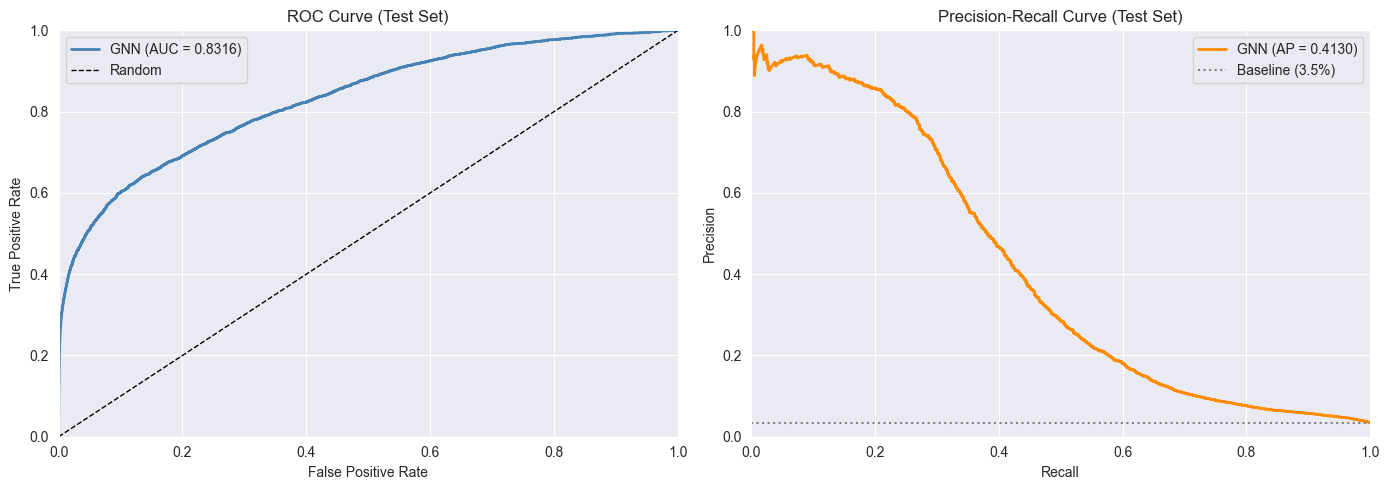

Saved → phase06_roc_pr_curves.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'GNN (AUC = {test_roc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Test Set)')
axes[0].legend()
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# PR Curve
prec, rec, _ = precision_recall_curve(test_labels, test_probs)
axes[1].plot(rec, prec, color='darkorange', linewidth=2, label=f'GNN (AP = {test_pr:.4f})')
baseline = test_labels.mean()
axes[1].axhline(baseline, color='gray', linestyle=':', label=f'Baseline ({baseline*100:.1f}%)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Test Set)')
axes[1].legend()
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(DATA_DIR / 'phase06_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → phase06_roc_pr_curves.png')

## 6.6 — Threshold Tuning & F1-Score

We sweep decision thresholds to find the one that maximizes F1-score on the test set.

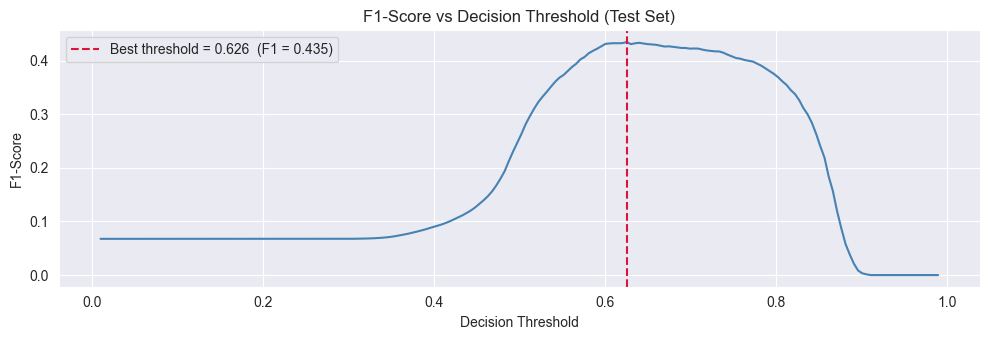

Optimal threshold : 0.6256
Best F1           : 0.4348


In [7]:
thresholds = np.linspace(0.01, 0.99, 200)
f1_scores = [f1_score(test_labels, (test_probs >= t).astype(int), zero_division=0) for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(thresholds, f1_scores, color='steelblue', linewidth=1.5)
ax.axvline(best_thresh, color='crimson', linestyle='--',
           label=f'Best threshold = {best_thresh:.3f}  (F1 = {best_f1:.3f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score vs Decision Threshold (Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'phase06_f1_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal threshold : {best_thresh:.4f}')
print(f'Best F1           : {best_f1:.4f}')

## 6.7 — Confusion Matrix & Classification Report

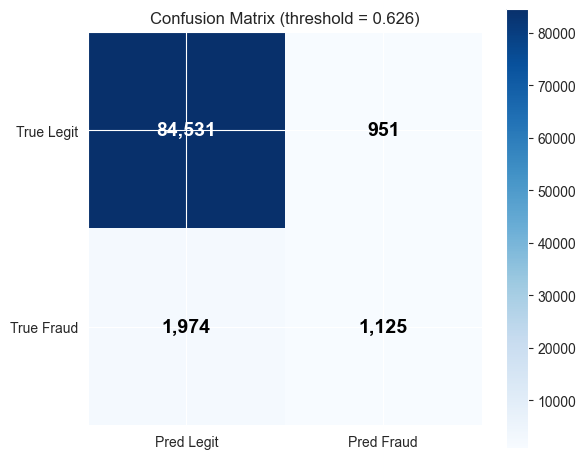


Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9772    0.9889    0.9830     85482
       Fraud     0.5419    0.3630    0.4348      3099

    accuracy                         0.9670     88581
   macro avg     0.7595    0.6759    0.7089     88581
weighted avg     0.9620    0.9670    0.9638     88581

True Positives  (caught fraud)  : 1,125
False Negatives (missed fraud)  : 1,974
False Positives (false alarms)  : 951
True Negatives  (correct legit) : 84,531
Fraud catch rate (recall)       : 36.3%
Alert precision                 : 54.2%


In [8]:
preds = (test_probs >= best_thresh).astype(int)
cm = confusion_matrix(test_labels, preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Legit', 'Pred Fraud'])
ax.set_yticklabels(['True Legit', 'True Fraud'])
ax.set_title(f'Confusion Matrix (threshold = {best_thresh:.3f})')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=14,
                fontweight='bold', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(DATA_DIR / 'phase06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(test_labels, preds, target_names=['Legitimate', 'Fraud'], digits=4))

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (caught fraud)  : {tp:,}')
print(f'False Negatives (missed fraud)  : {fn:,}')
print(f'False Positives (false alarms)  : {fp:,}')
print(f'True Negatives  (correct legit) : {tn:,}')
print(f'Fraud catch rate (recall)       : {tp/(tp+fn)*100:.1f}%')
print(f'Alert precision                 : {tp/(tp+fp)*100:.1f}%')

## 6.8 — Baseline Comparison: MLP vs GNN

We train a simple MLP on the flat transaction features (no graph structure) and compare against the GNN.
This isolates the contribution of the relational (graph) component.

In [10]:
from sklearn.neural_network import MLPClassifier
from scipy.special import expit

# Prepare flat data
x_all = data['transaction'].x.numpy()
y_all = data['transaction'].y.numpy()
train_mask = data['transaction'].train_mask.numpy()
test_mask = data['transaction'].test_mask.numpy()

x_train, y_train = x_all[train_mask], y_all[train_mask]
x_test, y_test = x_all[test_mask], y_all[test_mask]

# MLP baseline
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
)
mlp.fit(x_train, y_train)
mlp_probs = mlp.predict_proba(x_test)[:, 1]
mlp_roc = roc_auc_score(y_test, mlp_probs)
mlp_pr = average_precision_score(y_test, mlp_probs)

print(f'MLP Baseline — ROC-AUC: {mlp_roc:.4f}  |  PR-AUC: {mlp_pr:.4f}')
print(f'GNN Model    — ROC-AUC: {test_roc:.4f}  |  PR-AUC: {test_pr:.4f}')

# Comparison table
print('\n' + '='*55)
print(f'{"Model":<30} {"ROC-AUC":>10}  {"PR-AUC":>10}')
print('='*55)
print(f'{"MLP (flat features)":<30} {mlp_roc:>10.4f}  {mlp_pr:>10.4f}')
print(f'{"Relational GNN (ours)":<30} {test_roc:>10.4f}  {test_pr:>10.4f}')
print('='*55)

delta_roc = (test_roc - mlp_roc) / mlp_roc * 100

delta_pr = (test_pr - mlp_pr) / mlp_pr * 100
print(f'\nGNN vs MLP  →  ROC-AUC: {delta_roc:+.1f}%  |  PR-AUC: {delta_pr:+.1f}%')

MLP Baseline — ROC-AUC: 0.7802  |  PR-AUC: 0.4188
GNN Model    — ROC-AUC: 0.8316  |  PR-AUC: 0.4130

Model                             ROC-AUC      PR-AUC
MLP (flat features)                0.7802      0.4188
Relational GNN (ours)              0.8316      0.4130

GNN vs MLP  →  ROC-AUC: +6.6%  |  PR-AUC: -1.4%


## 6.9 — t-SNE Embedding Visualization

We visualize the GNN's learned transaction embeddings using t-SNE.
If the model has learned useful representations, fraudulent and legitimate transactions should separate in the embedding space.

Running t-SNE on 5000 samples...


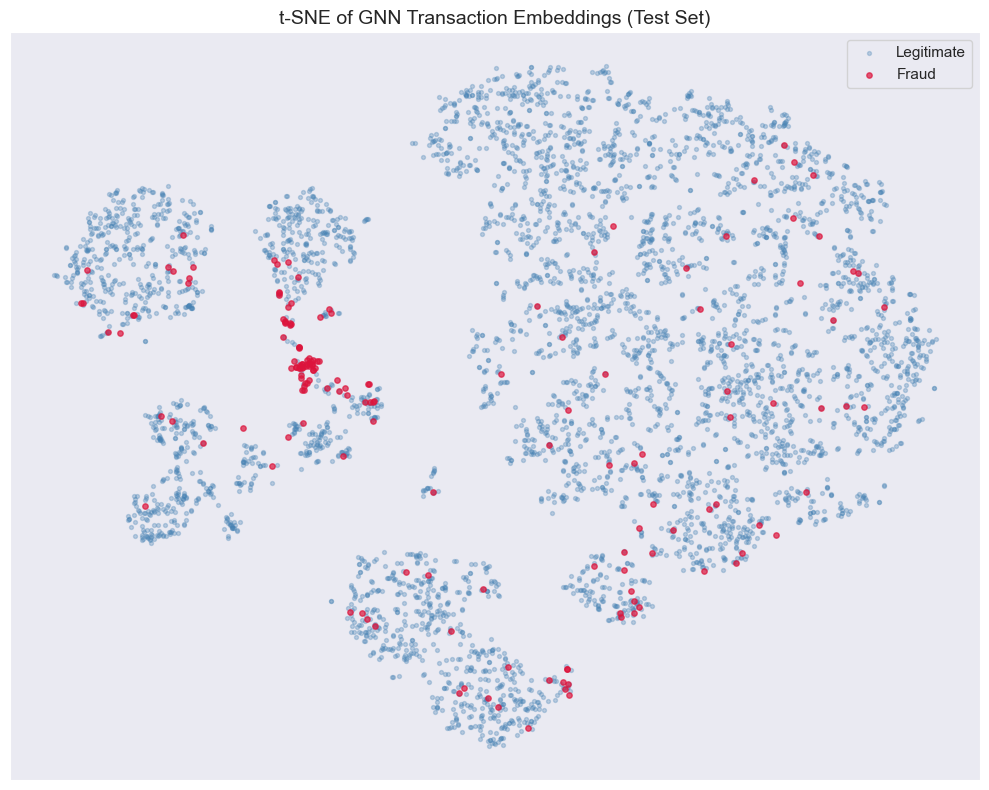

Saved → phase06_tsne_embeddings.png


In [14]:
if test_embeds is not None:
    # Subsample for speed
    N_SAMPLE = min(5000, len(test_labels))
    idx = np.random.choice(len(test_labels), N_SAMPLE, replace=False)
    sample_embeds = test_embeds[idx]
    sample_labels = test_labels[idx]

    print(f'Running t-SNE on {N_SAMPLE} samples...')
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    coords = tsne.fit_transform(sample_embeds)

    fig, ax = plt.subplots(figsize=(10, 8))
    legit_mask = sample_labels == 0
    fraud_mask = sample_labels == 1

    ax.scatter(coords[legit_mask, 0], coords[legit_mask, 1],
               c='steelblue', alpha=0.3, s=8, label='Legitimate')
    ax.scatter(coords[fraud_mask, 0], coords[fraud_mask, 1],
               c='crimson', alpha=0.7, s=15, label='Fraud')

    ax.set_title('t-SNE of GNN Transaction Embeddings (Test Set)', fontsize=14)
    ax.legend(fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'phase06_tsne_embeddings.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → phase06_tsne_embeddings.png')
else:
    print('No embeddings available — model forward() may not return them.')
    print('Skipping t-SNE visualization.')

## 6.10 — Ablation: Entity Contribution Analysis

We analyze which entity types (card1, email, device, etc.) contribute most to the graph structure
by examining edge counts and entity node statistics.

In [15]:
print(f'{"Edge Type":<50} {"Edges":>10}')
print('-' * 62)
for edge_type in sorted(data.edge_types, key=lambda et: data[et].edge_index.shape[1], reverse=True):
    n_edges = data[edge_type].edge_index.shape[1]
    print(f'{str(edge_type):<50} {n_edges:>10,}')

print(f'\n{"Node Type":<20} {"Nodes":>10} {"Feature Dim":>12}')
print('-' * 44)
for ntype in data.node_types:
    n_nodes = data[ntype].num_nodes
    feat_dim = data[ntype].x.shape[1] if hasattr(data[ntype], 'x') and data[ntype].x is not None else 0
    print(f'{ntype:<20} {n_nodes:>10,} {feat_dim:>12}')

Edge Type                                               Edges
--------------------------------------------------------------
('transaction', 'has_product', 'product')             590,540
('product', 'rev_has_product', 'transaction')         590,540
('transaction', 'has_card1', 'card1')                 590,540
('card1', 'rev_has_card1', 'transaction')             590,540
('transaction', 'has_card2', 'card2')                 590,540
('card2', 'rev_has_card2', 'transaction')             590,540
('transaction', 'has_card3', 'card3')                 590,540
('card3', 'rev_has_card3', 'transaction')             590,540
('transaction', 'has_card4', 'card4')                 590,540
('card4', 'rev_has_card4', 'transaction')             590,540
('transaction', 'has_card5', 'card5')                 590,540
('card5', 'rev_has_card5', 'transaction')             590,540
('transaction', 'has_card6', 'card6')                 590,540
('card6', 'rev_has_card6', 'transaction')             590,540
('trans

## 6.11 — Final Summary

In [16]:
print('╔══════════════════════════════════════════════════════════╗')
print('║          PHASE 06 — EVALUATION SUMMARY                  ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Test ROC-AUC            : {test_roc:.4f}                      ║')
print(f'║  Test PR-AUC             : {test_pr:.4f}                      ║')
print(f'║  Best F1 (thresh={best_thresh:.3f}) : {best_f1:.4f}                      ║')
print(f'║  Fraud Recall            : {tp/(tp+fn)*100:.1f}%                       ║')
print(f'║  Alert Precision         : {tp/(tp+fp)*100:.1f}%                       ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  Saved Artifacts:                                       ║')
print(f'║    ROC & PR curves → phase06_roc_pr_curves.png         ║')
print(f'║    F1 threshold    → phase06_f1_threshold.png          ║')
print(f'║    Confusion matrix→ phase06_confusion_matrix.png      ║')
print(f'║    t-SNE plot      → phase06_tsne_embeddings.png       ║')
print('╚══════════════════════════════════════════════════════════╝')
print('\nPhase 06 complete.')

╔══════════════════════════════════════════════════════════╗
║          PHASE 06 — EVALUATION SUMMARY                  ║
╠══════════════════════════════════════════════════════════╣
║  Test ROC-AUC            : 0.8316                      ║
║  Test PR-AUC             : 0.4130                      ║
║  Best F1 (thresh=0.626) : 0.4348                      ║
║  Fraud Recall            : 36.3%                       ║
║  Alert Precision         : 54.2%                       ║
╠══════════════════════════════════════════════════════════╣
║  Saved Artifacts:                                       ║
║    ROC & PR curves → phase06_roc_pr_curves.png         ║
║    F1 threshold    → phase06_f1_threshold.png          ║
║    Confusion matrix→ phase06_confusion_matrix.png      ║
║    t-SNE plot      → phase06_tsne_embeddings.png       ║
╚══════════════════════════════════════════════════════════╝

Phase 06 complete.
